In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

In [4]:
p1 = 0.05  # 甲方每枚核弹被摧毁的概率
p2 = 0.05  # 乙方每枚核弹被摧毁的概率
x0 = 20    # 甲方希望剩余的最少核弹数
y0 = 20    # 乙方希望剩余的最少核弹数
x_range = np.arange(10, 101)  # 甲方的核弹数范围
y_range = np.arange(10, 101)  # 乙方的核弹数范围

In [5]:
# 定义计算无差别曲线的函数
def indiff_curve(x_range, y_range, p, x0):
    curve = []
    for x in x_range:
        min_y = None
        for y in y_range:
            prob = sum(binom.pmf(k, x, 1-(1-p)**y) for k in range(x0, x+1))
            if prob >= 0.9:
                min_y = y
                break
        if min_y is not None:
            curve.append((x, min_y))
    return np.array(curve)

In [11]:
# 计算甲方和乙方的无差别曲线
indiff_curve_a = indiff_curve(x_range, x_range, p1, x0)
indiff_curve_b = indiff_curve(x_range, x_range, p2, y0)

# 安全区域应该是两条曲线以上的交集部分
min_y_for_a = np.interp(x_range, indiff_curve_a[:, 0], indiff_curve_a[:, 1], left=100, right=100)
min_y_for_b = np.interp(x_range, indiff_curve_b[:, 0], indiff_curve_b[:, 1], left=100, right=100)
common_safe_y = np.maximum(min_y_for_a, min_y_for_b)

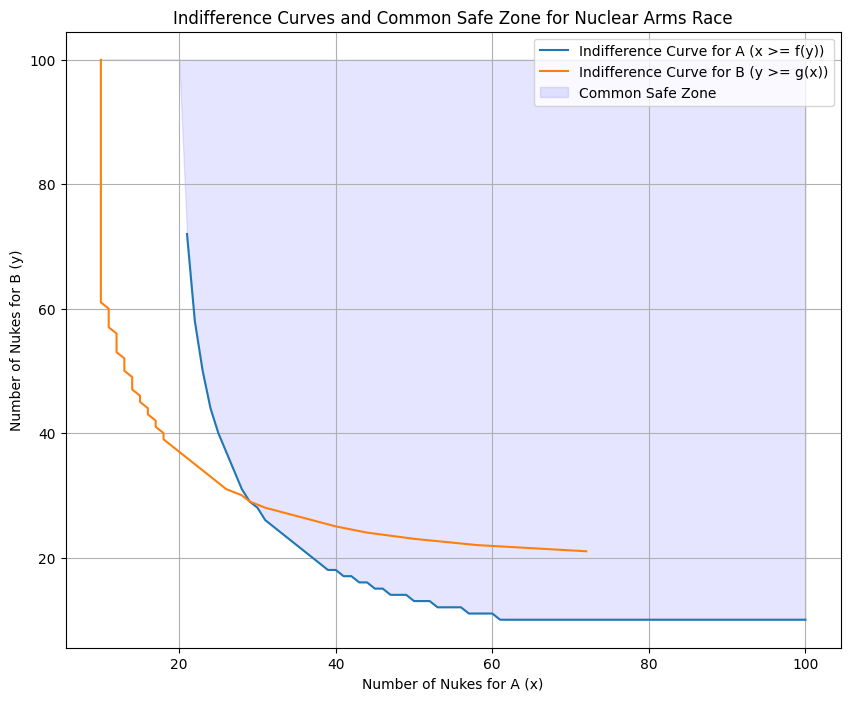

In [12]:
# 绘制无差别曲线和安全区域
plt.figure(figsize=(10, 8))
plt.plot(indiff_curve_a[:, 0], indiff_curve_a[:, 1], label='Indifference Curve for A (x >= f(y))')
plt.plot(indiff_curve_b[:, 1], indiff_curve_b[:, 0], label='Indifference Curve for B (y >= g(x))')

# 绘制安全区域
plt.fill_between(x_range, common_safe_y, 100, color='blue', alpha=0.1, label='Common Safe Zone')

plt.xlabel('Number of Nukes for A (x)')
plt.ylabel('Number of Nukes for B (y)')
plt.title('Indifference Curves and Common Safe Zone for Nuclear Arms Race')
plt.legend()
plt.grid(True)
plt.show()